# 0_04 — MEROPS seen through the serum classes

## Scope

`0_01` measures the MEROPS matrices as objects, without asking which enzymes they
belong to. `0_02` and `0_03` establish the classes the serum panel is cut along:
catalytic family, event geometry, serum category and circulating amount. This
notebook puts the two together and asks the question neither can answer alone:
**does the quality of a MEROPS matrix depend on what kind of enzyme it describes?**

That matters because every later notebook aggregates over proteases. If matrix
quality were independent of class, an aggregate would be a fair summary. If the
well-determined matrices all belong to one family and the uninformative ones to
another, then an aggregate silently reports the first family and the panel needs
to be cut before it is summed.

The notebook also states which peptidases cannot be carried forward at all, and
on what grounds, rather than letting them fall out of a later join unremarked.

## The three grounds for rejection

| Ground | Meaning |
| --- | --- |
| no matrix | MEROPS records no cleavage for this code, so there is nothing to score with |
| uninformative matrix | the matrix exists but its specificity does not exceed what its own cleavage count would produce by chance |
| unresolvable identity | the EC number is missing or the UniProt mapping is ambiguous, so the enzyme cannot be tied to a kinetic measurement |

These are different failures and are reported separately. A peptidase with no
matrix is invisible to the model; one with an uninformative matrix is worse,
because it will produce a score that looks like every other score.

## Execution contract

**Inputs:** `results/0_01_merops_serum_panel_audit.csv`; `results/0_02_serum_protease_geometry.csv`; `results/0_03_hpa_abundance_per_protease.csv`.

**Outputs:** `results/0_04_class_quality.csv`; `results/0_04_rejections.csv`; `results/0_04_class_tests.csv`.

**Depends on:** `0_01`, `0_02`, `0_03`.

**Boundary:** Associations by protease class do not imply class-specific serum cleavage rates.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal, spearmanr

import _analysis_common as common

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# Verdicts from 0_01 that disqualify a matrix from carrying a score.
UNUSABLE_VERDICTS = ("uninformative",)
# Mapping states from 0_02 that leave an enzyme unable to be tied to a measurement.
UNRESOLVED_MAPPING = ("unresolved_multiple_human_mappings", "unresolved_no_human_mapping")
# A class with fewer members than this cannot support a comparison of its own.
MIN_CLASS_SIZE = 3
# Below this many recorded cleavages a matrix is treated as thin, for the summary only.
THIN_MATRIX_CLEAVAGES = 50
SEED = common.SEED

In [3]:
audit = pd.read_csv(common.RESULTS_ROOT / "0_01_merops_serum_panel_audit.csv").rename(columns={"code": "merops_code"})
geometry = pd.read_csv(common.RESULTS_ROOT / "0_02_serum_protease_geometry.csv")
abundance = pd.read_csv(common.RESULTS_ROOT / "0_03_hpa_abundance_per_protease.csv")

abundance["abundance_pg_per_l"] = abundance[["ms_pg_per_l", "immunoassay_pg_per_l"]].max(axis=1)
panel = (
    geometry.merge(
        audit[["merops_code", "n_cleavages", "mean_divergence_excess", "median_rank_stability",
               "p10_rank_stability", "merops_matrix_verdict", "median_subsite_depth"]],
        on="merops_code", how="left", suffixes=("", "_audit"),
    )
    .merge(abundance[["merops_code", "abundance_pg_per_l", "has_any_measurement"]], on="merops_code", how="left")
)
panel["family_class"] = panel["merops_family"].str.extract(r"^([A-Z])")[0].map(
    {"A": "aspartic", "C": "cysteine", "M": "metallo", "S": "serine", "T": "threonine"}
).fillna("other")
panel["has_matrix"] = panel["n_cleavages"].fillna(0) > 0
panel["thin_matrix"] = panel["n_cleavages"].fillna(0) < THIN_MATRIX_CLEAVAGES

print(f"serum panel entries: {len(panel)}")
print(f"  with a MEROPS matrix: {int(panel['has_matrix'].sum())}")
print(f"  with an abundance estimate: {int(panel['abundance_pg_per_l'].notna().sum())}")
print()
print(panel.groupby("family_class").size().to_string())

serum panel entries: 55
  with a MEROPS matrix: 55
  with an abundance estimate: 42

family_class
cysteine     1
metallo     17
serine      37


## Does matrix quality depend on the class?

Three quantities describe a matrix: how much evidence it rests on, how far its
subsites depart from the proteome background, and how reproducibly it ranks bonds
under resampling of its own cleavages. Each is compared across catalytic family
and across event geometry with a Kruskal-Wallis test, which asks only whether the
groups are drawn from one distribution and makes no assumption about its shape.

In [4]:
QUANTITIES = {
    "n_cleavages": "cleavages behind the matrix",
    "mean_divergence_excess": "specificity above its own sampling floor",
    "median_rank_stability": "reproducibility of the bond ranking",
}
CLASSES = {"family_class": "catalytic family", "event_geometry": "event geometry"}

tests = []
for class_column, class_label in CLASSES.items():
    for quantity, quantity_label in QUANTITIES.items():
        groups = [
            values[quantity].dropna().to_numpy()
            for _, values in panel.groupby(class_column)
            if len(values[quantity].dropna()) >= MIN_CLASS_SIZE
        ]
        if len(groups) < 2:
            continue
        statistic, p_value = kruskal(*groups)
        tests.append(
            {
                "class": class_label,
                "quantity": quantity_label,
                "groups_compared": len(groups),
                "kruskal_h": float(statistic),
                "p_value": float(p_value),
            }
        )
tests_frame = pd.DataFrame(tests)
print(tests_frame.round(4).to_string(index=False))

class_quality = (
    panel.groupby(["family_class", "event_geometry"])
    .agg(
        peptidases=("merops_code", "size"),
        with_matrix=("has_matrix", "sum"),
        median_cleavages=("n_cleavages", "median"),
        median_divergence_excess=("mean_divergence_excess", "median"),
        median_rank_stability=("median_rank_stability", "median"),
        uninformative=("merops_matrix_verdict", lambda v: int((v == "uninformative").sum())),
        well_determined=("merops_matrix_verdict", lambda v: int((v == "well_determined").sum())),
    )
    .reset_index()
)
print()
print(class_quality.round(3).to_string(index=False))

           class                                 quantity  groups_compared  kruskal_h  p_value
catalytic family              cleavages behind the matrix                2     2.6297   0.1049
catalytic family specificity above its own sampling floor                2     0.0008   0.9777
catalytic family      reproducibility of the bond ranking                2     5.9982   0.0143
  event geometry              cleavages behind the matrix                3     2.9177   0.2325
  event geometry specificity above its own sampling floor                3     3.7092   0.1565
  event geometry      reproducibility of the bond ranking                3     3.3523   0.1871

family_class       event_geometry  peptidases  with_matrix  median_cleavages  median_divergence_excess  median_rank_stability  uninformative  well_determined
    cysteine        non_hydrolase           1            1               1.0                     0.129                  0.870              1                0
     metallo      

### Reading the figure

Each panel splits one measure of matrix quality by one class. A class whose points
sit systematically higher has better matrices, and an aggregate over the whole
panel would then be reporting that class rather than the panel. The dashed line in
the stability panel is the level at which half the bond ranking survives
resampling.

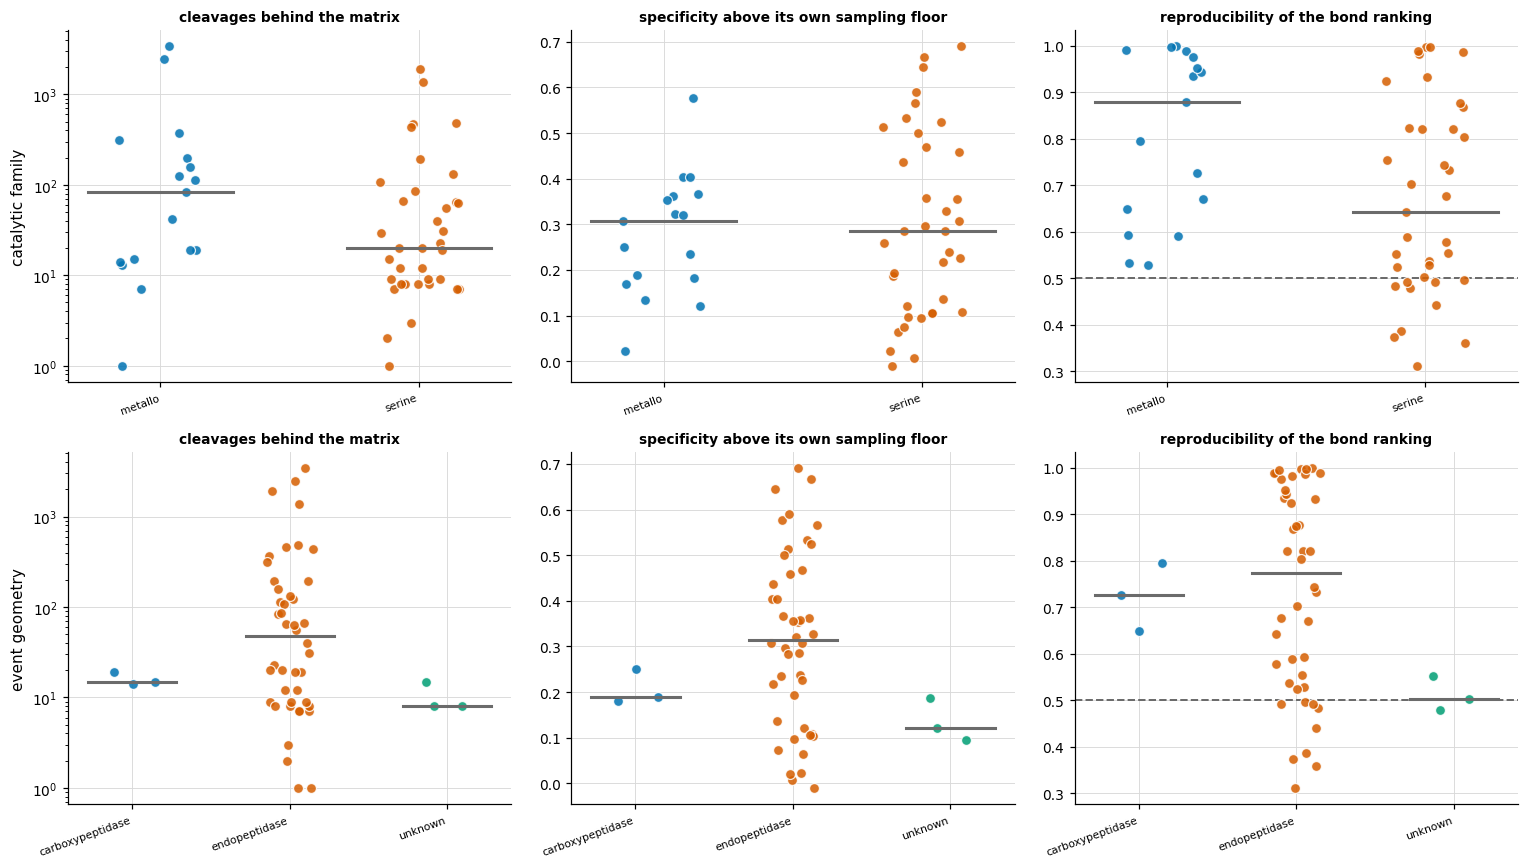

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14.0, 8.0))
for row, (class_column, class_label) in enumerate(CLASSES.items()):
    order = [c for c, g in panel.groupby(class_column) if len(g) >= MIN_CLASS_SIZE]
    for column, (quantity, quantity_label) in enumerate(QUANTITIES.items()):
        ax = axes[row, column]
        for position, group_name in enumerate(order):
            values = panel.loc[panel[class_column] == group_name, quantity].dropna().to_numpy()
            ax.scatter(
                np.full(len(values), position) + np.random.default_rng(position + row).uniform(-0.16, 0.16, len(values)),
                values, s=42, color=common.CATEGORICAL_COLORS[position % 6], alpha=0.85,
                edgecolor="white", linewidth=0.8, zorder=3,
            )
            if len(values):
                ax.plot([position - 0.28, position + 0.28], [np.median(values)] * 2,
                        color=common.NEUTRAL, linewidth=2.0, zorder=4)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, fontsize=7, rotation=20, ha="right")
        if quantity == "n_cleavages":
            ax.set_yscale("log")
        if quantity == "median_rank_stability":
            ax.axhline(0.5, color=common.NEUTRAL, linestyle="--", linewidth=1.3)
        if column == 0:
            ax.set_ylabel(class_label)
        ax.set_title(quantity_label, fontsize=9)
fig.tight_layout()
plt.show()

**Provenance**

This figure joins three derived tables by MEROPS code: `results/0_01_merops_serum_panel_audit.csv` (MEROPS 2023 count and score audit), `results/0_02_serum_protease_geometry.csv` (manifest and UniProt/EC geometry), and `results/0_03_hpa_abundance_per_protease.csv` (HPA blood abundance). One point is one code, grouped by its `serum_category` or `event_geometry`; `0_04` does not add independent source observations. Inspect the join and class test in code cells 4–6, then the code-level records in the three input tables.

> **Caveat.** This notebook reads `results/0_01_merops_serum_panel_audit.csv`, but the current `0_01` writes `results/0_01_merops_matrices.csv`. The former exists as an older saved artifact; a fresh sequential run would not regenerate it from `0_01`. Counts are protease-code counts, not cleavage events; class differences can reflect source coverage and missing HPA values.


## Is a well-determined matrix also an abundant enzyme?

A separate worry: the model weights each protease by how much of it circulates,
so if the abundant enzymes were the ones with the worst matrices, the weighting
would be amplifying the least reliable part of the panel.

proteases with both an abundance and a stability: 42
  abundance against ranking stability: rho -0.495, p 0.001
  abundance against cleavage count:    rho -0.466, p 0.002


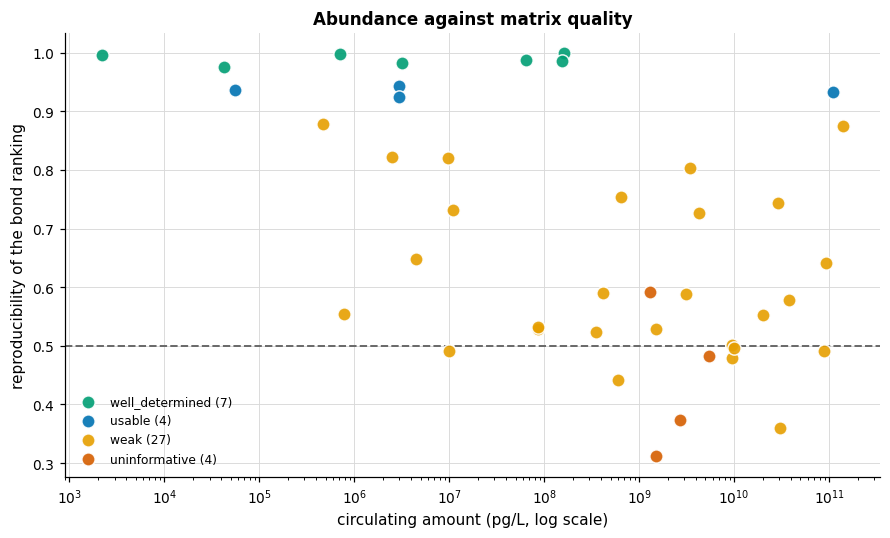

In [6]:
with_both = panel.dropna(subset=["abundance_pg_per_l", "median_rank_stability"])
correlation = spearmanr(np.log10(with_both["abundance_pg_per_l"]), with_both["median_rank_stability"])
evidence_correlation = spearmanr(np.log10(with_both["abundance_pg_per_l"]), with_both["n_cleavages"].fillna(0) + 1)
print(f"proteases with both an abundance and a stability: {len(with_both)}")
print(f"  abundance against ranking stability: rho {correlation.statistic:+.3f}, p {correlation.pvalue:.3f}")
print(f"  abundance against cleavage count:    rho {evidence_correlation.statistic:+.3f}, p {evidence_correlation.pvalue:.3f}")

fig, ax = plt.subplots(figsize=(8.2, 5.0))
for verdict, colour in zip(
    ("well_determined", "usable", "weak", "uninformative"),
    (common.CATEGORICAL_COLORS[2], common.CATEGORICAL_COLORS[0], common.CATEGORICAL_COLORS[3], common.CATEGORICAL_COLORS[1]),
):
    subset = with_both[with_both["merops_matrix_verdict"] == verdict]
    ax.scatter(subset["abundance_pg_per_l"], subset["median_rank_stability"], s=75, color=colour,
               alpha=0.9, edgecolor="white", linewidth=1.0, zorder=3, label=f"{verdict} ({len(subset)})")
ax.set_xscale("log")
ax.axhline(0.5, color=common.NEUTRAL, linestyle="--", linewidth=1.3)
ax.set_xlabel("circulating amount (pg/L, log scale)")
ax.set_ylabel("reproducibility of the bond ranking")
ax.set_title("Abundance against matrix quality")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Which peptidases cannot be carried forward

Each ground is applied separately and a peptidase may fail on more than one. The
table is the explicit version of what a later join would otherwise do silently.

In [7]:
panel["rejected_no_matrix"] = ~panel["has_matrix"]
panel["rejected_uninformative"] = panel["merops_matrix_verdict"].isin(UNUSABLE_VERDICTS)
panel["rejected_unresolved_identity"] = panel["mapping_status"].isin(UNRESOLVED_MAPPING)
panel["rejected"] = (
    panel["rejected_no_matrix"] | panel["rejected_uninformative"] | panel["rejected_unresolved_identity"]
)

rejections = panel.loc[
    panel["rejected"],
    ["merops_code", "merops_name", "merops_family", "family_class", "event_geometry", "serum_category",
     "n_cleavages", "merops_matrix_verdict", "mapping_status", "abundance_pg_per_l",
     "rejected_no_matrix", "rejected_uninformative", "rejected_unresolved_identity"],
].sort_values(["rejected_no_matrix", "rejected_uninformative"], ascending=False)

summary = pd.DataFrame(
    {
        "ground": ["no matrix", "uninformative matrix", "unresolvable identity", "rejected on any ground", "carried forward"],
        "peptidases": [
            int(panel["rejected_no_matrix"].sum()),
            int(panel["rejected_uninformative"].sum()),
            int(panel["rejected_unresolved_identity"].sum()),
            int(panel["rejected"].sum()),
            int((~panel["rejected"]).sum()),
        ],
    }
)
print(summary.to_string(index=False))
print()
print(rejections[["merops_code", "merops_name", "n_cleavages", "merops_matrix_verdict", "mapping_status"]].to_string(index=False))

                ground  peptidases
             no matrix           0
  uninformative matrix           5
 unresolvable identity           4
rejected on any ground           8
       carried forward          47

merops_code                             merops_name  n_cleavages merops_matrix_verdict                     mapping_status
   C111.001                coagulation factor XIIIa            1         uninformative        unresolved_no_human_mapping
    M12.241                      ADAMTS13 peptidase            1         uninformative                    mapped_reviewed
    S01.189 complement component C1r-like peptidase            1         uninformative                    mapped_reviewed
    S01.191                     complement factor D            3         uninformative                    mapped_reviewed
    S01.228      hepatocyte growth factor activator            2         uninformative                    mapped_reviewed
    M14.004                      carboxypeptidase N      

In [8]:
common.save_result(class_quality, "0_04_class_quality.csv")
common.save_result(rejections, "0_04_rejections.csv")
common.save_result(tests_frame, "0_04_class_tests.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_04_class_tests.csv')

## Findings and decisions

**Matrix quality is not independent of catalytic family.** The reproducibility of
the bond ranking differs between the metallo and serine families at
$H = 6.00$, $p = 0.014$, while the amount of evidence and the specificity excess do
not differ significantly. Event geometry separates none of the three. The practical
consequence is narrow but real: an aggregate over the whole panel that involves
ranking stability is reporting the better-ranked family rather than the panel, and
has to be read per family.

**The most abundant enzymes have the worst-characterised matrices.** Circulating
amount correlates **negatively** with the reproducibility of the bond ranking,
$\rho = -0.495$, $p = 0.001$, and with the number of recorded cleavages,
$\rho = -0.466$, $p = 0.002$, over the 42 proteases carrying both. This is the
single most consequential result in this notebook, because the hazard model
multiplies a score by an abundance: the concentration weighting amplifies exactly
the part of the panel whose specificity is least reliable. It also explains from
the data side why `4_01` finds thrombin dominating the hazard of most peptides
while sitting in the `assumed` validation tier — thrombin is abundant, and abundant
enzymes here are the thinly characterised ones.

The likely mechanism is not mysterious. A protein abundant in plasma is studied for
what it does physiologically, on a handful of natural substrates, and not profiled
against substrate libraries; a protease of interest as a drug target accumulates
hundreds of synthetic cleavages. MEROPS counts the second kind.

**Eight of fifty-five peptidases cannot be carried forward, on two distinct
grounds.** Five have an **uninformative** matrix — coagulation factor XIIIa,
ADAMTS13, the C1r-like peptidase, complement factor D and hepatocyte growth factor
activator, each resting on one to three recorded cleavages. This is the dangerous
failure, because such a matrix still produces a score, and that score is
indistinguishable in form from an informative one; only the verdict recorded in
`0_01` says otherwise. Four more have an **unresolvable identity** — carboxypeptidase
N and the two tryptases map to several human UniProt records, factor XIIIa to none —
so they cannot be tied to a kinetic measurement whatever their matrix says.

No panel entry lacks a matrix entirely. Forty-seven are carried forward.